# Importação de Pacotes

In [16]:
#leitura da base de dados
import pandas as pd
from pathlib import Path

#modelo preditivo escolhido
import catboost as cb
from catboost import CatBoostClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer

In [17]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(
        ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)
    )

    print(f"""
      Acurária: {round(acuracia,3)};
      Revocação: {round(recall,3)};
      F1: {round(F1,3)};
      Roc_Auc: {round(roc_auc,3)}""")

## Leitura DataFrame

In [18]:
direcao = Path("../..") / "data"
caminho = direcao / "dados_confrontados_completo.csv"

df = pd.read_csv(caminho)

### Escolha do Modelo

In [19]:
modelo= CatBoostClassifier()

### Escolha dos HiperParâmetros

In [20]:
parametros = {
    "modelo__iterations": [500],
    "modelo__learning_rate": [0.2],
    "modelo__depth": [6],
    "modelo__verbose": [0]
}

# Aplicação de Pipelines

In [21]:
lista_X = ["materialidade_valor", "materialidade_categoria", "legitimidade_representante", "tipo_legitimidade", "clareza_objetividade", 
        "fundamentacao_minima", "indicios_irregularidade", "competencia_tcu", "recursos_federais", "demanda_privada", "interesse_publico",
        "type_restricao_admissibilidade", "type_evidencia_indicio_minimo", "type_aceitabilidade_evidencia_jornalistica",
        "type_nivel_indicio", "pedido_medida_cautelar", "contrato_vigente", "contrato_iminente", "criticidade_objeto", "certame_suspenso",
        'risco_erario', 'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe', 'type_contrato_objeto_previsto', 
        'type_regularizacao_requisito', 'type_defesa_ente_administrativo', 'type_impacto_irregularidade', 'perigo_demora_reverso', 
        'fumus_boni_iuris', 'categoria_irregularidade','dano_potencial_alto', 'dano_potencial_medio', 'nexo_causal_identificado',
        'resposta_ente_apresentada', 'evidencia_jogo_planilha', 'evidencia_sobrepreco', 'evidencia_inexequibilidade', 'evidencia_direcionamento',
        'conformidade_qualif_tecnica', 'conformidade_julgamento_objetivo', 'descumprimento_edital_tr', 'parcelamento_inadequado', 
        'pesquisa_precos_inadequada', 'exigencia_marca_referencia', 'atestados_restritivos', 'indices_contabeis_inadequados',
        'garantias_excessivas', 'prazo_inadequado', 'modalidade_licitacao_inadequada', 'dispensa_inexigibilidade_indevida',
        'falta_publicidade', 'quebra_sigilo', 'exigencia_local_inadequada', 'certificacao_restritiva', 'vinculo_trabalhista_inadequado',
        'consorcio_inadequado', 'subcontratacao_inadequada', 'violacao_legalidade', 'violacao_isonomia', 'violacao_vinculacao_edital', 
        'violacao_moralidade', 'violacao_publicidade', 'violacao_eficiencia', 'evidencias_edital_original', 'evidencias_propostas_licitantes',
        'evidencias_atas_julgamento', 'evidencias_contratos_aditivos', 'evidencias_pareceres_tecnicos', 'evidencias_pesquisa_precos',
        'evidencias_correspondencias_oficiais','evidencias_impugnacoes_recursos', 'evidencias_relatorios_fiscalizacao', 
        'evidencias_documentos_contabeis', 'evidencias_midiaticas', 'evidencias_testemunhais', 'qualidade_evidencias_forte',
        'qualidade_evidencias_moderada', 'autenticidade_documentos_certificada', 'autenticidade_documentos_presumida', 'resposta_ente_convincente']

X = df[lista_X]

y = df["y_exame_sumario"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#transformando coluna númerica em float64 (no df original encontra-se como str)
def numerico(coluna):
    return(pd.to_numeric(coluna.squeeze(), errors="coerce").to_frame())

num_prep = Pipeline(steps=[
    ('tranformer_num', FunctionTransformer(numerico)),
    ('imputer', SimpleImputer(strategy='median'))
])

#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["materialidade_valor"]),
        ('cat', cat_prep, lista_X)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=5
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__depth': [6], 'modelo__iterations': [500], 'modelo__learning_rate': [0.2], 'modelo__verbose': [0]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.72;
      Revocação: 0.36;
      F1: 0.427;
      Roc_Auc: 0.614


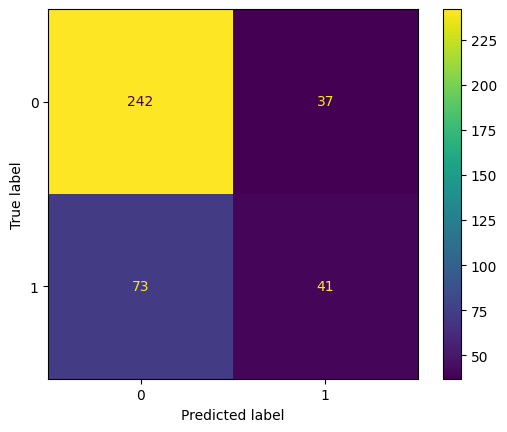

In [22]:
estimadores(searchCV_pipeline, X_test, y_test)

## **Teste com mais Parâmetros**

In [26]:
parametros = {
    "modelo__iterations": [500, 800],
    "modelo__learning_rate": [0.2],
    "modelo__depth": [4, 6, 8],
    "modelo__verbose": [0]
}

In [27]:
lista_X = ["materialidade_valor", "materialidade_categoria", "legitimidade_representante", "tipo_legitimidade", "clareza_objetividade", 
        "fundamentacao_minima", "indicios_irregularidade", "competencia_tcu", "recursos_federais", "demanda_privada", "interesse_publico",
        "type_restricao_admissibilidade", "type_evidencia_indicio_minimo", "type_aceitabilidade_evidencia_jornalistica",
        "type_nivel_indicio", "pedido_medida_cautelar", "contrato_vigente", "contrato_iminente", "criticidade_objeto", "certame_suspenso",
        'risco_erario', 'urgencia_temporal', 'perigo_demora', 'type_contrato_objeto_existe', 'type_contrato_objeto_previsto', 
        'type_regularizacao_requisito', 'type_defesa_ente_administrativo', 'type_impacto_irregularidade', 'perigo_demora_reverso', 
        'fumus_boni_iuris', 'categoria_irregularidade','dano_potencial_alto', 'dano_potencial_medio', 'nexo_causal_identificado',
        'resposta_ente_apresentada', 'evidencia_jogo_planilha', 'evidencia_sobrepreco', 'evidencia_inexequibilidade', 'evidencia_direcionamento',
        'conformidade_qualif_tecnica', 'conformidade_julgamento_objetivo', 'descumprimento_edital_tr', 'parcelamento_inadequado', 
        'pesquisa_precos_inadequada', 'exigencia_marca_referencia', 'atestados_restritivos', 'indices_contabeis_inadequados',
        'garantias_excessivas', 'prazo_inadequado', 'modalidade_licitacao_inadequada', 'dispensa_inexigibilidade_indevida',
        'falta_publicidade', 'quebra_sigilo', 'exigencia_local_inadequada', 'certificacao_restritiva', 'vinculo_trabalhista_inadequado',
        'consorcio_inadequado', 'subcontratacao_inadequada', 'violacao_legalidade', 'violacao_isonomia', 'violacao_vinculacao_edital', 
        'violacao_moralidade', 'violacao_publicidade', 'violacao_eficiencia', 'evidencias_edital_original', 'evidencias_propostas_licitantes',
        'evidencias_atas_julgamento', 'evidencias_contratos_aditivos', 'evidencias_pareceres_tecnicos', 'evidencias_pesquisa_precos',
        'evidencias_correspondencias_oficiais','evidencias_impugnacoes_recursos', 'evidencias_relatorios_fiscalizacao', 
        'evidencias_documentos_contabeis', 'evidencias_midiaticas', 'evidencias_testemunhais', 'qualidade_evidencias_forte',
        'qualidade_evidencias_moderada', 'autenticidade_documentos_certificada', 'autenticidade_documentos_presumida', 'resposta_ente_convincente']

X = df[lista_X]

y = df["y_exame_sumario"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


#transformando coluna númerica em float64 (no df original encontra-se como str)
def numerico(coluna):
    return(pd.to_numeric(coluna.squeeze(), errors="coerce").to_frame())

num_prep = Pipeline(steps=[
    ('tranformer_num', FunctionTransformer(numerico)),
    ('imputer', SimpleImputer(strategy='median'))
])

#pipeline de dummies
cat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ["materialidade_valor"]),
        ('cat', cat_prep, lista_X)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc',
    refit='roc_auc',
    cv=10
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__depth': [4, 6, ...], 'modelo__iterations': [500, 800], 'modelo__learning_rate': [0.2], 'modelo__verbose': [0]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,None
,refit,'roc_auc'
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



      Acurária: 0.73;
      Revocação: 0.395;
      F1: 0.459;
      Roc_Auc: 0.631


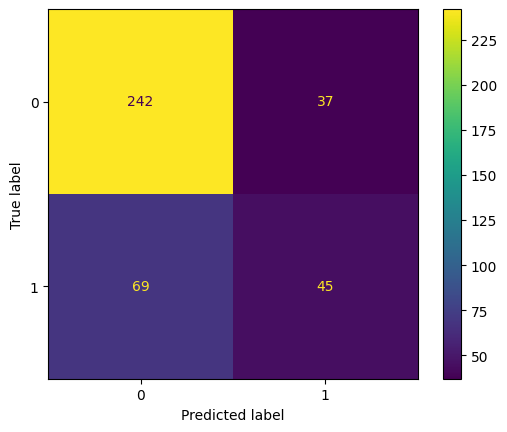

In [28]:
estimadores(searchCV_pipeline, X_test, y_test)